In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [5]:
from google.colab import files
uploaded = files.upload()

Saving sample_submission.csv to sample_submission.csv
Saving car_crash_train.csv to car_crash_train.csv
Saving car_crash_test.csv to car_crash_test.csv


In [7]:
import pandas as pd

train = pd.read_csv("car_crash_train.csv")
test = pd.read_csv("car_crash_test.csv")
sample_submission = pd.read_csv("sample_submission.csv")

In [8]:
print("Train shape:", train.shape)
print("Test shape:", test.shape)
print("Sample submission shape:", sample_submission.shape)

Train shape: (4000, 19)
Test shape: (1000, 19)
Sample submission shape: (5000, 2)


In [9]:
train.head()

,Crash Speed (km/h),Impact Angle (degrees),Airbag Deployed,Seatbelt Used,Weather Conditions,Road Conditions,Crash Type,Vehicle Type,Vehicle Age (years),Brake Condition,Tire Condition,Driver Age,Driver Experience (years),Alcohol Level (BAC%),Distraction Level,Time of Day,Traffic Density,Visibility Distance (m),Severity
0,182,69,Yes,No,Clear,Dry,Rollover,Sedan,5,Good,Good,23,11,0.025314,NaN,Morning,Low,213,Minor Injury
1,192,73,Yes,No,Clear,Dry,Head-on,Truck,3,Good,Good,29,27,0.002372,Phone,Morning,Medium,426,Minor Injury
2,114,77,No,Yes,Clear,Dry,Head-on,Sedan,16,Good,Worn out,73,45,0.000483,NaN,Morning,Medium,175,Minor Injury
3,93,14,No,Yes,Clear,Dry,Rear-end,Truck,14,Worn out,Worn out,27,18,0.176578,NaN,Afternoon,Medium,82,Minor Injury
4,170,96,No,Yes,Clear,Dry,Side impact,SUV,15,Good,Good,70,27,0.065696,Other,Morning,Medium,96,Severe Injury


In [10]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 19 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Crash Speed (km/h)         4000 non-null   int64  
 1   Impact Angle (degrees)     4000 non-null   int64  
 2   Airbag Deployed            4000 non-null   object 
 3   Seatbelt Used              4000 non-null   object 
 4   Weather Conditions         4000 non-null   object 
 5   Road Conditions            4000 non-null   object 
 6   Crash Type                 4000 non-null   object 
 7   Vehicle Type               4000 non-null   object 
 8   Vehicle Age (years)        4000 non-null   int64  
 9   Brake Condition            4000 non-null   object 
 10  Tire Condition             4000 non-null   object 
 11  Driver Age                 4000 non-null   int64  
 12  Driver Experience (years)  4000 non-null   int64  
 13  Alcohol Level (BAC%)       4000 non-null   float

In [11]:
train.isnull().sum()

,0
Crash Speed (km/h),0
Impact Angle (degrees),0
Airbag Deployed,0
Seatbelt Used,0
Weather Conditions,0
Road Conditions,0
Crash Type,0
Vehicle Type,0
Vehicle Age (years),0
Brake Condition,0


In [12]:

train_clean = train.copy()
test_clean = test.copy()


train_clean["Distraction Level"] = train_clean["Distraction Level"].fillna("Unknown")
test_clean["Distraction Level"] = test_clean["Distraction Level"].fillna("Unknown")


train_clean.isnull().sum()

,0
Crash Speed (km/h),0
Impact Angle (degrees),0
Airbag Deployed,0
Seatbelt Used,0
Weather Conditions,0
Road Conditions,0
Crash Type,0
Vehicle Type,0
Vehicle Age (years),0
Brake Condition,0


In [13]:
train_clean["Severity"].value_counts()

,count
Severity,
Minor Injury,2756
Severe Injury,1038
Fatal,206


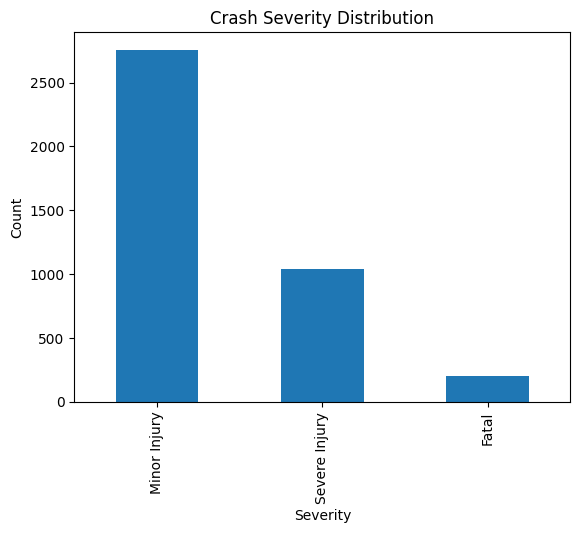

In [14]:
train_clean["Severity"].value_counts().plot(kind="bar")

plt.title("Crash Severity Distribution")
plt.xlabel("Severity")
plt.ylabel("Count")

plt.show()

In [15]:
train_clean.describe()

,Crash Speed (km/h),Impact Angle (degrees),Vehicle Age (years),Driver Age,Driver Experience (years),Alcohol Level (BAC%),Visibility Distance (m)
count,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000
mean,110.999750,89.979750,9.445500,48.698750,24.723000,0.101216,247.583500
std,52.227839,51.301514,5.718147,17.815972,14.211818,0.057820,143.478155
min,20.000000,0.000000,0.000000,18.000000,0.000000,0.000054,10.000000
25%,66.000000,45.000000,5.000000,34.000000,13.000000,0.050630,120.000000
50%,112.000000,89.500000,9.000000,49.000000,25.000000,0.101574,244.000000
75%,157.000000,134.000000,14.000000,64.000000,37.000000,0.151783,372.000000
max,199.000000,179.000000,19.000000,79.000000,49.000000,0.199936,499.000000


Descriptive statistics were computed for all numerical features in the dataset. The results show that crash speeds range from 20 km/h to 199 km/h, with an average speed of approximately 111 km/h. Driver ages range from 18 to 79 years with an average of around 49 years. Visibility distance also varies significantly, ranging from 10 m to 499 m. These statistics help understand the distribution and range of numerical features before training machine learning models.

In [16]:
X = train_clean.drop("Severity", axis=1)
y = train_clean["Severity"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (4000, 18)
Target shape: (4000,)


In [17]:
numerical_cols = X.select_dtypes(include=["int64", "float64"]).columns
categorical_cols = X.select_dtypes(include=["object"]).columns

print("Numerical columns:")
print(numerical_cols)

print("\nCategorical columns:")
print(categorical_cols)

Numerical columns:
Index(['Crash Speed (km/h)', 'Impact Angle (degrees)', 'Vehicle Age (years)',
       'Driver Age', 'Driver Experience (years)', 'Alcohol Level (BAC%)',
       'Visibility Distance (m)'],
      dtype='object')

Categorical columns:
Index(['Airbag Deployed', 'Seatbelt Used', 'Weather Conditions',
       'Road Conditions', 'Crash Type', 'Vehicle Type', 'Brake Condition',
       'Tire Condition', 'Distraction Level', 'Time of Day',
       'Traffic Density'],
      dtype='object')


In [18]:
from sklearn.model_selection import train_test_split

X_train, X_valid, y_train, y_valid = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_valid:", X_valid.shape)
print("y_train:", y_train.shape)
print("y_valid:", y_valid.shape)

X_train: (3200, 18)
X_valid: (800, 18)
y_train: (3200,)
y_valid: (800,)


In [19]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols)
    ]
)

X_train_processed = preprocessor.fit_transform(X_train)
X_valid_processed = preprocessor.transform(X_valid)

print("Processed X_train shape:", X_train_processed.shape)
print("Processed X_valid shape:", X_valid_processed.shape)

Processed X_train shape: (3200, 41)
Processed X_valid shape: (800, 41)


One-Hot Encoding was selected for categorical variables because the categorical features do not have a natural order. This method converts each category into binary 0/1 columns, allowing machine learning models to process categorical data without assuming false ranking between categories. Numerical features were scaled using StandardScaler.

In [20]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

In [21]:
log_model = LogisticRegression(max_iter=5000)

log_model.fit(X_train_processed, y_train)

LogisticRegression(max_iter=5000)

In [22]:
y_pred_log = log_model.predict(X_valid_processed)

In [23]:
log_accuracy = accuracy_score(y_valid, y_pred_log)

print("Logistic Regression Accuracy:", log_accuracy)

Logistic Regression Accuracy: 0.68875


In [24]:
print(classification_report(y_valid, y_pred_log))

               precision    recall  f1-score   support

        Fatal       0.00      0.00      0.00        41
 Minor Injury       0.69      1.00      0.82       551
Severe Injury       0.00      0.00      0.00       208

     accuracy                           0.69       800
    macro avg       0.23      0.33      0.27       800
 weighted avg       0.47      0.69      0.56       800



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Logistic Regression achieved an accuracy of approximately 68.9%. However, the classification report revealed that the model predicted almost all observations as Minor Injury due to the class imbalance in the dataset. As a result, the model failed to correctly classify Fatal and Severe Injury cases, leading to very low recall and F1-scores for minority classes. This demonstrates that accuracy alone is not sufficient for evaluating imbalanced classification problems.

In [25]:
from sklearn.tree import DecisionTreeClassifier

tree_model = DecisionTreeClassifier(random_state=42)

tree_model.fit(X_train_processed, y_train)

y_pred_tree = tree_model.predict(X_valid_processed)

tree_accuracy = accuracy_score(y_valid, y_pred_tree)

print("Decision Tree Accuracy:", tree_accuracy)

print(classification_report(y_valid, y_pred_tree))

Decision Tree Accuracy: 0.54125
               precision    recall  f1-score   support

        Fatal       0.08      0.10      0.09        41
 Minor Injury       0.69      0.66      0.68       551
Severe Injury       0.29      0.30      0.30       208

     accuracy                           0.54       800
    macro avg       0.35      0.35      0.35       800
 weighted avg       0.55      0.54      0.55       800



The Decision Tree model achieved lower accuracy than Logistic Regression. However, unlike Logistic Regression, it attempted to classify all severity classes, including Fatal and Severe Injury. This shows that accuracy alone is not enough for comparison, especially because the dataset is imbalanced.

In [26]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(random_state=42)

rf_model.fit(X_train_processed, y_train)

y_pred_rf = rf_model.predict(X_valid_processed)

rf_accuracy = accuracy_score(y_valid, y_pred_rf)

print("Random Forest Accuracy:", rf_accuracy)
print(classification_report(y_valid, y_pred_rf))

Random Forest Accuracy: 0.6875
               precision    recall  f1-score   support

        Fatal       0.00      0.00      0.00        41
 Minor Injury       0.69      1.00      0.81       551
Severe Injury       0.00      0.00      0.00       208

     accuracy                           0.69       800
    macro avg       0.23      0.33      0.27       800
 weighted avg       0.47      0.69      0.56       800



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Random Forest achieved an accuracy similar to Logistic Regression. However, the model still failed to correctly classify Fatal and Severe Injury cases due to the strong class imbalance in the dataset. Although Random Forest is generally a powerful ensemble model, the imbalance caused the model to favor the dominant Minor Injury class.

In [27]:
from sklearn.neighbors import KNeighborsClassifier

knn_model = KNeighborsClassifier(n_neighbors=5)

knn_model.fit(X_train_processed, y_train)

y_pred_knn = knn_model.predict(X_valid_processed)

knn_accuracy = accuracy_score(y_valid, y_pred_knn)

print("KNN Accuracy:", knn_accuracy)

print(classification_report(y_valid, y_pred_knn))

KNN Accuracy: 0.63625
               precision    recall  f1-score   support

        Fatal       0.00      0.00      0.00        41
 Minor Injury       0.69      0.88      0.77       551
Severe Injury       0.27      0.11      0.15       208

     accuracy                           0.64       800
    macro avg       0.32      0.33      0.31       800
 weighted avg       0.54      0.64      0.57       800



KNN achieved an accuracy of approximately 63.6%. The model performed reasonably well for the dominant Minor Injury class but struggled to classify minority classes such as Fatal and Severe Injury. Since KNN relies on distances between observations, feature scaling was important before training the model.

In [28]:
from sklearn.naive_bayes import GaussianNB

nb_model = GaussianNB()

nb_model.fit(X_train_processed, y_train)

y_pred_nb = nb_model.predict(X_valid_processed)

nb_accuracy = accuracy_score(y_valid, y_pred_nb)

print("Naive Bayes Accuracy:", nb_accuracy)

print(classification_report(y_valid, y_pred_nb))

Naive Bayes Accuracy: 0.635
               precision    recall  f1-score   support

        Fatal       0.09      0.05      0.06        41
 Minor Injury       0.69      0.89      0.77       551
Severe Injury       0.27      0.09      0.13       208

     accuracy                           0.64       800
    macro avg       0.35      0.34      0.32       800
 weighted avg       0.55      0.64      0.57       800



Naive Bayes achieved moderate accuracy but still struggled with minority classes due to the imbalance in the dataset. Although it was able to classify some Fatal and Severe Injury cases, the overall performance remained lower than Logistic Regression and Random Forest.

In [29]:
log_balanced = LogisticRegression(max_iter=5000, class_weight="balanced")

log_balanced.fit(X_train_processed, y_train)

y_pred_log_balanced = log_balanced.predict(X_valid_processed)

log_balanced_accuracy = accuracy_score(y_valid, y_pred_log_balanced)

print("Balanced Logistic Regression Accuracy:", log_balanced_accuracy)
print(classification_report(y_valid, y_pred_log_balanced))

Balanced Logistic Regression Accuracy: 0.33625
               precision    recall  f1-score   support

        Fatal       0.04      0.29      0.08        41
 Minor Injury       0.72      0.34      0.46       551
Severe Injury       0.26      0.35      0.30       208

     accuracy                           0.34       800
    macro avg       0.34      0.32      0.28       800
 weighted avg       0.57      0.34      0.40       800



In [30]:
tree_balanced = DecisionTreeClassifier(
    random_state=42,
    class_weight="balanced"
)

tree_balanced.fit(X_train_processed, y_train)

y_pred_tree_balanced = tree_balanced.predict(X_valid_processed)

tree_balanced_accuracy = accuracy_score(y_valid, y_pred_tree_balanced)

print("Balanced Decision Tree Accuracy:", tree_balanced_accuracy)
print(classification_report(y_valid, y_pred_tree_balanced))

Balanced Decision Tree Accuracy: 0.545
               precision    recall  f1-score   support

        Fatal       0.05      0.05      0.05        41
 Minor Injury       0.69      0.69      0.69       551
Severe Injury       0.27      0.26      0.27       208

     accuracy                           0.55       800
    macro avg       0.33      0.33      0.33       800
 weighted avg       0.54      0.55      0.54       800



In [31]:
rf_balanced = RandomForestClassifier(
    random_state=42,
    class_weight="balanced"
)

rf_balanced.fit(X_train_processed, y_train)

y_pred_rf_balanced = rf_balanced.predict(X_valid_processed)

rf_balanced_accuracy = accuracy_score(y_valid, y_pred_rf_balanced)

print("Balanced Random Forest Accuracy:", rf_balanced_accuracy)
print(classification_report(y_valid, y_pred_rf_balanced))

Balanced Random Forest Accuracy: 0.68875
               precision    recall  f1-score   support

        Fatal       0.00      0.00      0.00        41
 Minor Injury       0.69      1.00      0.82       551
Severe Injury       0.00      0.00      0.00       208

     accuracy                           0.69       800
    macro avg       0.23      0.33      0.27       800
 weighted avg       0.47      0.69      0.56       800



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [32]:
knn_weighted = KNeighborsClassifier(
    n_neighbors=5,
    weights="distance"
)

knn_weighted.fit(X_train_processed, y_train)

y_pred_knn_weighted = knn_weighted.predict(X_valid_processed)

knn_weighted_accuracy = accuracy_score(y_valid, y_pred_knn_weighted)

print("Weighted KNN Accuracy:", knn_weighted_accuracy)
print(classification_report(y_valid, y_pred_knn_weighted))

Weighted KNN Accuracy: 0.635
               precision    recall  f1-score   support

        Fatal       0.00      0.00      0.00        41
 Minor Injury       0.69      0.87      0.77       551
Severe Injury       0.28      0.12      0.17       208

     accuracy                           0.64       800
    macro avg       0.32      0.33      0.31       800
 weighted avg       0.55      0.64      0.58       800



In [33]:
nb_balanced = GaussianNB(
    priors=[1/3, 1/3, 1/3]
)

nb_balanced.fit(X_train_processed, y_train)

y_pred_nb_balanced = nb_balanced.predict(X_valid_processed)

nb_balanced_accuracy = accuracy_score(y_valid, y_pred_nb_balanced)

print("Balanced Naive Bayes Accuracy:", nb_balanced_accuracy)
print(classification_report(y_valid, y_pred_nb_balanced))

Balanced Naive Bayes Accuracy: 0.375
               precision    recall  f1-score   support

        Fatal       0.04      0.27      0.07        41
 Minor Injury       0.72      0.42      0.53       551
Severe Injury       0.27      0.28      0.28       208

     accuracy                           0.38       800
    macro avg       0.35      0.32      0.29       800
 weighted avg       0.57      0.38      0.44       800



Balanced and weighted versions of the models were evaluated to reduce the effect of class imbalance. While the balancing techniques reduced overall accuracy, they improved the detection of minority classes such as Fatal and Severe Injury. This demonstrates the tradeoff between overall accuracy and minority-class recall in imbalanced classification problems. Among the balanced models, the Balanced Decision Tree provided a better compromise between accuracy and minority-class detection.

In [34]:
final_results = {
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "KNN",
        "Naive Bayes",
        "Balanced Logistic Regression",
        "Balanced Decision Tree",
        "Balanced Random Forest",
        "Weighted KNN",
        "Balanced Naive Bayes"
    ],

    "Accuracy": [
        log_accuracy,
        tree_accuracy,
        rf_accuracy,
        knn_accuracy,
        nb_accuracy,
        log_balanced_accuracy,
        tree_balanced_accuracy,
        rf_balanced_accuracy,
        knn_weighted_accuracy,
        nb_balanced_accuracy
    ]
}

final_results_df = pd.DataFrame(final_results)

final_results_df

,Model,Accuracy
0,Logistic Regression,0.68875
1,Decision Tree,0.54125
2,Random Forest,0.68750
3,KNN,0.63625
4,Naive Bayes,0.63500
5,Balanced Logistic Regression,0.33625
6,Balanced Decision Tree,0.54500
7,Balanced Random Forest,0.68875
8,Weighted KNN,0.63500
9,Balanced Naive Bayes,0.37500


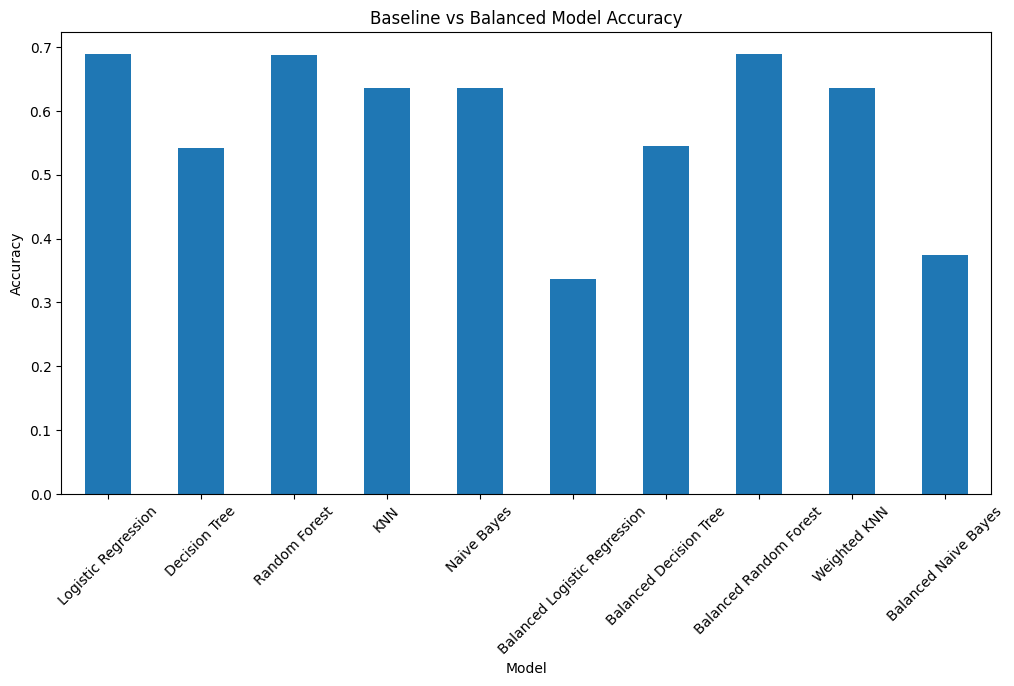

In [35]:
final_results_df.plot(
    x="Model",
    y="Accuracy",
    kind="bar",
    figsize=(12,6),
    legend=False
)

plt.title("Baseline vs Balanced Model Accuracy")
plt.ylabel("Accuracy")
plt.xticks(rotation=45)

plt.show()

In [36]:
log_reg_l2 = LogisticRegression(
    max_iter=5000,
    class_weight="balanced",
    penalty="l2",
    C=1.0
)

log_reg_l2.fit(X_train_processed, y_train)

y_pred_log_l2 = log_reg_l2.predict(X_valid_processed)

log_reg_l2_accuracy = accuracy_score(y_valid, y_pred_log_l2)

print("Regularized Balanced Logistic Regression Accuracy:", log_reg_l2_accuracy)
print(classification_report(y_valid, y_pred_log_l2))

Regularized Balanced Logistic Regression Accuracy: 0.33625
               precision    recall  f1-score   support

        Fatal       0.04      0.29      0.08        41
 Minor Injury       0.72      0.34      0.46       551
Severe Injury       0.26      0.35      0.30       208

     accuracy                           0.34       800
    macro avg       0.34      0.32      0.28       800
 weighted avg       0.57      0.34      0.40       800



In [37]:
final_results = {
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "KNN",
        "Naive Bayes",
        "Balanced Logistic Regression",
        "Balanced Decision Tree",
        "Balanced Random Forest",
        "Weighted KNN",
        "Balanced Naive Bayes",
        "Regularized Balanced Logistic Regression"
    ],
    "Accuracy": [
        log_accuracy,
        tree_accuracy,
        rf_accuracy,
        knn_accuracy,
        nb_accuracy,
        log_balanced_accuracy,
        tree_balanced_accuracy,
        rf_balanced_accuracy,
        knn_weighted_accuracy,
        nb_balanced_accuracy,
        log_reg_l2_accuracy
    ]
}

final_results_df = pd.DataFrame(final_results)
final_results_df.sort_values(by="Accuracy", ascending=False)

,Model,Accuracy
0,Logistic Regression,0.68875
7,Balanced Random Forest,0.68875
2,Random Forest,0.68750
3,KNN,0.63625
8,Weighted KNN,0.63500
4,Naive Bayes,0.63500
6,Balanced Decision Tree,0.54500
1,Decision Tree,0.54125
9,Balanced Naive Bayes,0.37500
5,Balanced Logistic Regression,0.33625


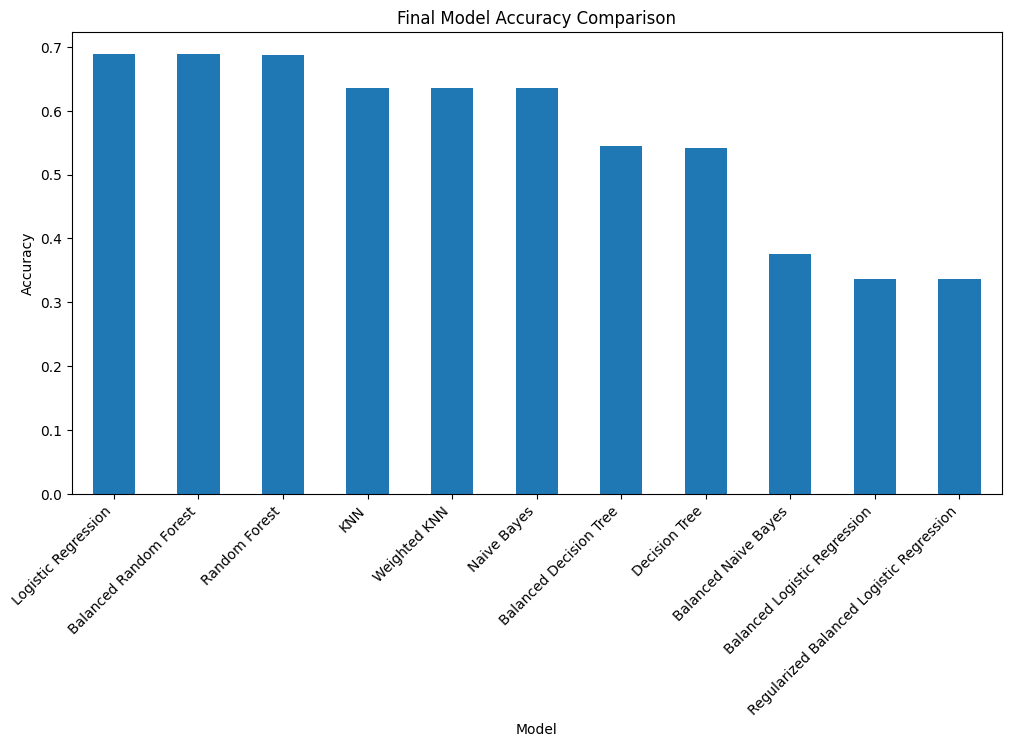

In [38]:
final_results_df.sort_values(by="Accuracy", ascending=False).plot(
    x="Model",
    y="Accuracy",
    kind="bar",
    figsize=(12, 6),
    legend=False
)

plt.title("Final Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.xticks(rotation=45, ha="right")
plt.show()

Although Balanced Decision Tree improved minority-class detection, Logistic Regression achieved the highest overall validation accuracy. Since the project evaluation is mainly based on prediction performance on the test set, Logistic Regression was selected as the final model. However, if minority class recall is prioritized, Balanced Decision Tree would be the preferred model.

In [39]:
final_model = LogisticRegression(max_iter=5000)

# Fit on FULL dataset
final_model.fit(
    preprocessor.fit_transform(X),
    y
)

LogisticRegression(max_iter=5000)

In [40]:
test_processed = preprocessor.transform(test_clean)

In [41]:
test_predictions = final_model.predict(test_processed)

In [42]:
sample_submission.head()

,ID,Predicted_Severity
0,5ca30a05-b855-4cf3-915f-a92a6be7c010,Minor Injury
1,cc90ec30-fbb8-4f72-8814-8df3b82ea995,Severe Injury
2,a35b1df3-d476-4e21-b4be-54356572decb,Fatal
3,3f6e8e90-e5e7-4f49-93b2-64c1970839ce,Fatal
4,68829fcb-2211-40b4-a9a0-d06a8c6c970c,Severe Injury


In [43]:
print(test_clean.shape)
print(sample_submission.shape)

(1000, 19)
(5000, 2)


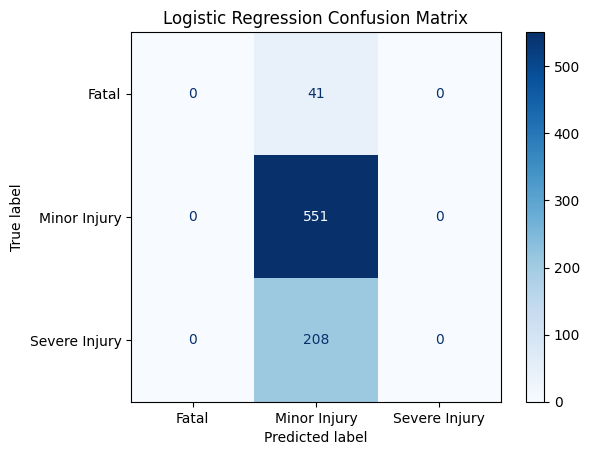

In [44]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_valid, y_pred_log)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=log_model.classes_
)

disp.plot(cmap="Blues")

plt.title("Logistic Regression Confusion Matrix")

plt.show()

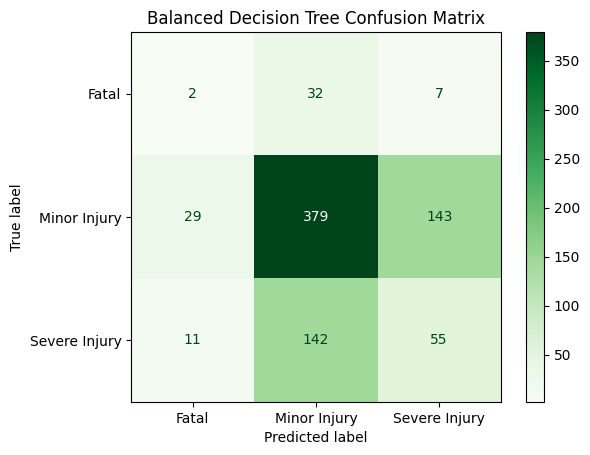

In [45]:
cm_tree = confusion_matrix(y_valid, y_pred_tree_balanced)

disp_tree = ConfusionMatrixDisplay(
    confusion_matrix=cm_tree,
    display_labels=tree_balanced.classes_
)

disp_tree.plot(cmap="Greens")

plt.title("Balanced Decision Tree Confusion Matrix")

plt.show()

In [46]:
feature_names = preprocessor.get_feature_names_out()

importances = rf_model.feature_importances_

importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
})

importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)

importance_df.head(10)

,Feature,Importance
6,num__Visibility Distance (m),0.093473
5,num__Alcohol Level (BAC%),0.092885
1,num__Impact Angle (degrees),0.092694
0,num__Crash Speed (km/h),0.092142
3,num__Driver Age,0.083669
4,num__Driver Experience (years),0.082868
2,num__Vehicle Age (years),0.070173
11,cat__Weather Conditions_Clear,0.015577
22,cat__Crash Type_Side impact,0.014710
20,cat__Crash Type_Rear-end,0.014394


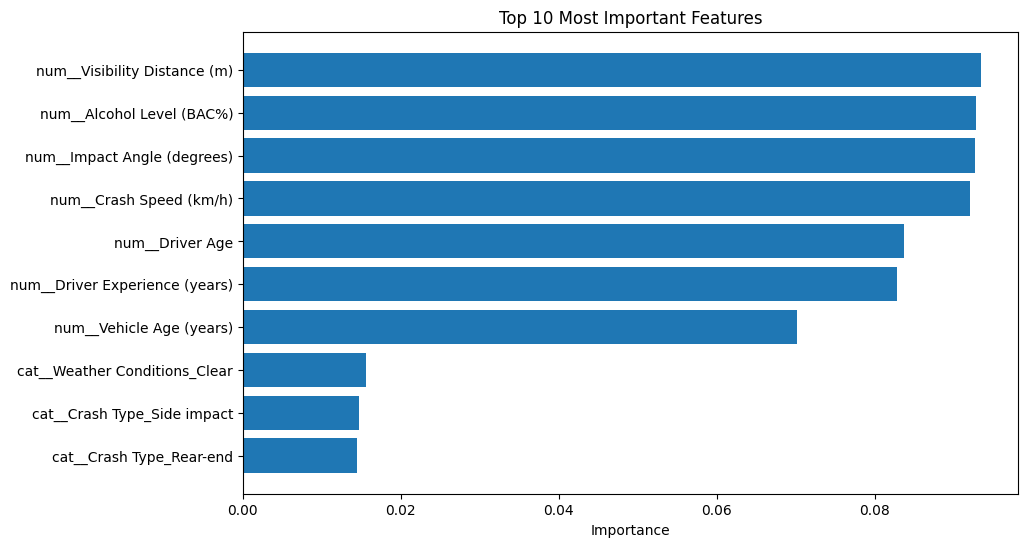

In [47]:
top_features = importance_df.head(10)

plt.figure(figsize=(10,6))

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.gca().invert_yaxis()

plt.title("Top 10 Most Important Features")
plt.xlabel("Importance")

plt.show()

In [48]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "n_estimators": [50, 100],
    "max_depth": [None, 5, 10]
}

grid_rf = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=3,
    scoring="accuracy"
)

grid_rf.fit(X_train_processed, y_train)

print("Best Parameters:", grid_rf.best_params_)
print("Best Score:", grid_rf.best_score_)

Best Parameters: {'max_depth': 5, 'n_estimators': 50}
Best Score: 0.6890626346246161


This project explored multiple machine learning classification techniques for predicting car crash severity. Logistic Regression and Random Forest achieved the highest overall accuracy, while balanced models improved the detection of minority classes such as Fatal and Severe Injury. The results demonstrated the challenges caused by class imbalance and highlighted the importance of using multiple evaluation metrics beyond accuracy. Additional techniques such as confusion matrices, feature importance analysis, and hyperparameter tuning were also applied to strengthen model evaluation and interpretation.